In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
stock = pd.read_csv('stock_data.csv', parse_dates=['date'])
stock.head()

,Unnamed: 0,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,2020-01-02 00:00:00+00:00,300.35,300.60,295.19,296.24,33911864,72.406338,72.466606,71.162400,71.415527,135647456,0.0,1.0
1,1,2020-01-03 00:00:00+00:00,297.43,300.58,296.50,297.15,36633878,71.702404,72.461785,71.478206,71.634904,146535512,0.0,1.0
2,2,2020-01-06 00:00:00+00:00,299.80,299.96,292.75,293.79,29644644,72.273748,72.312319,70.574182,70.824898,118578576,0.0,1.0
3,3,2020-01-07 00:00:00+00:00,298.39,300.90,297.48,299.84,27877655,71.933835,72.538928,71.714458,72.283391,111510620,0.0,1.0
4,4,2020-01-08 00:00:00+00:00,303.19,304.44,297.16,297.16,33090946,73.090986,73.392327,71.637314,71.637314,132363784,0.0,1.0


In [7]:
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Unnamed: 0   1258 non-null   int64              
 1   date         1258 non-null   datetime64[us, UTC]
 2   close        1258 non-null   float64            
 3   high         1258 non-null   float64            
 4   low          1258 non-null   float64            
 5   open         1258 non-null   float64            
 6   volume       1258 non-null   int64              
 7   adjClose     1258 non-null   float64            
 8   adjHigh      1258 non-null   float64            
 9   adjLow       1258 non-null   float64            
 10  adjOpen      1258 non-null   float64            
 11  adjVolume    1258 non-null   int64              
 12  divCash      1258 non-null   float64            
 13  splitFactor  1258 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(

In [10]:
stock= stock[['date', 'close', 'volume', 'open', 'high', 'low'  ]].dropna()
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    1258 non-null   datetime64[us, UTC]
 1   close   1258 non-null   float64            
 2   volume  1258 non-null   int64              
 3   open    1258 non-null   float64            
 4   high    1258 non-null   float64            
 5   low     1258 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(4), int64(1)
memory usage: 59.1 KB


In [12]:
stock=stock.sort_values('date')

In [14]:
# Create lag features (previous day's values)
stock['prev_close'] = stock['close'].shift(1)
stock['prev_open'] = stock['open'].shift(1)
stock['prev_high'] = stock['high'].shift(1)
stock['prev_low'] = stock['low'].shift(1)
stock['prev_volume'] = stock['volume'].shift(1)

In [15]:
stock =stock.dropna()  # Drop rows with NaN values from lag features    

In [16]:
# define features and target variable  
x= stock[['prev_close', 'prev_open', 'prev_high', 'prev_low', 'prev_volume']]
y= stock['close']

In [17]:
# Train-test split(time-based)
split_index = int(len(stock) * 0.8)
x_train, x_test = x[:split_index], x[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [19]:
# train linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
# make predictions
y_pred = model.predict(x_test)

In [22]:
# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')

Mean Squared Error: 10.42
R^2 Score: 0.98


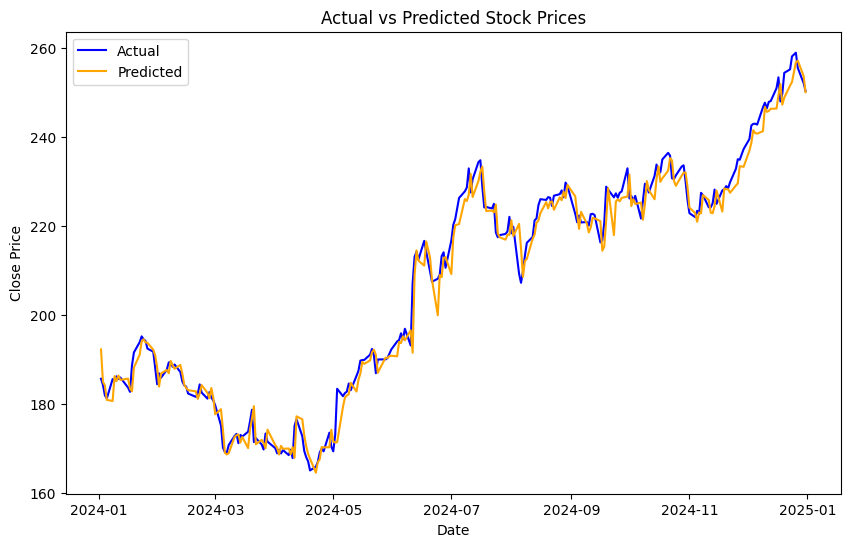

In [24]:
# plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(stock['date'][split_index:], y_test, label='Actual', color='blue')
plt.plot(stock['date'][split_index:], y_pred, label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Stock Prices')   
plt.legend()
plt.show()